<a href="https://colab.research.google.com/github/MiguelR0462/Integracion_de_Datos_y_Prospectiva/blob/main/Parcial_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parcial II – Gestión Prospectiva de Riesgos**
### Caso de Estudio: Fallas Tecnológicas – Sector FINTECH

Miguel Robledo Mejia

Integración de Datos y Prospectiva de Riesgo

Universidad EAFIT

**Objetivo:**  
Implementar un sistema de gestión prospectiva de riesgos operacionales basado en la distribución agregada de pérdidas (LDA) y el método de clusterización K-Means, con el fin de estimar el **Valor Capturado Financiero** como proxy del potencial de captura de Gases de Efecto Invernadero (GEI).

**Variables del modelo:**
- **Frecuencia (Xf):** Transacciones Fallidas por día
- **Severidad (Xs):** Valor Generado Promedio por falla (Millones USD)
- **LDA:** Distribución Agregada de Pérdidas = Xf × Xs

**Metodología:**  
K-Means sobre LDA - Matrices de Riesgo - Métricas de Pérdida Esperada - Valor Capturado

0. Cargamos los archivos, librerias y montamos el drive

In [ ]:
# montamos el drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# cargamos las librerias de trabajo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargamos los datos
path = "/content/drive/MyDrive/Universidad/Semestre 8/Integracion de Datos y Prospectiva de Riesgo/Archivos/5. Riesgo Operacional FallasTecnológicas.xlsx"
XDB = pd.read_excel(path)
XDB.head(5)

,Fallas Tecnológicas (Canales Electronicos),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado Promedio (Millones),Descripción Evento
1,2009-01-01 00:00:00,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
2,2009-01-02 00:00:00,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
3,2009-01-03 00:00:00,70,9.976,5,0.4269,"Errores visuales menores, problemas de usabili..."
4,2009-01-04 00:00:00,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."


In [ ]:
# volvemos la primera fila en los titulos
XDB.columns = XDB.iloc[0]
XDB = XDB[1:].reset_index(drop=True)
XDB.head()

,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado Promedio (Millones),Descripción Evento
0,2009-01-01 00:00:00,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02 00:00:00,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03 00:00:00,70,9.976,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04 00:00:00,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05 00:00:00,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


1. Creamos la funcion de clusterizacion

In [ ]:
def clusterizacion(Xi):

  #proceso de clusterizacion
  XC=np.random.choice(Xi,size=5)
  XC=np.sort(XC) #semillas de la clusterizacion (Improbable, Posible, Ocasional, Probable y Frecuente)
  nc=np.zeros((len(Xi),1)) #clasifico los datos en cada una de las semillas

  for k in range(len(Xi)):
    d=np.abs(XC-Xi[k]) # Distancia de cada dato a cada semilla
    nc[k]=np.argmin(d)
    nc2=np.int32(nc[k]) # Numero de pertenencia al cluster en enteros
    XC[nc2,]=(XC[nc2,]+Xi[k])/2 # Actualizamos la semilla a la que pertenece cada dato (K-medoids)

  return XC,nc # Me retorna clusters y cluster al que pertenece el dato

2. Empezamos la clusterizacion

In [ ]:
np.random.seed(42)

#obtenemos la variable de frecuencia
Xf=np.array(XDB.iloc[:,3])

XCf,ncf=clusterizacion(Xf)

# Obtenemos los cluster para la severidad
Xs=np.array(XDB.iloc[:,4])

XCs,ncs=clusterizacion(Xs)

# Se procede a determinar la distribucion de las perdidas
LDA=Xf*Xs
XClda,nclda=clusterizacion(LDA)

# Creamos un df de descargar
df=pd.DataFrame(np.column_stack((Xf,ncf,Xs,ncs,LDA,nclda,XDB.iloc[:,5])))
df.columns=['Freq','Nivel_f','Sev','Nivel_S','LDA','Nivel_LDA','Riesgos']
df.to_excel('MatrizRiesgo.xlsx')

4. Procedemos con la construcción de la matriz de eventos de riesgo

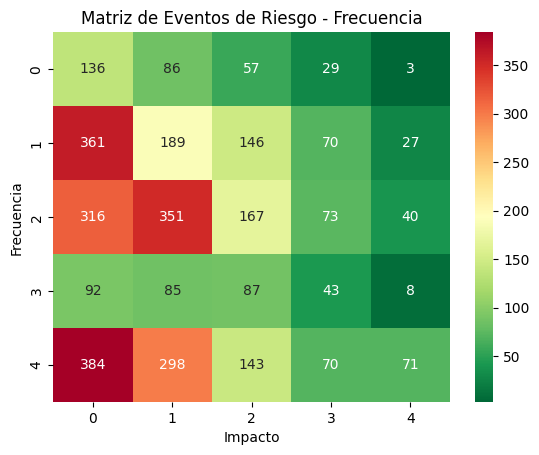

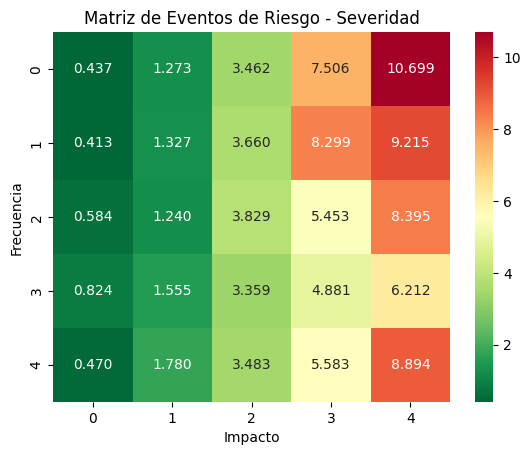

In [ ]:
MEf=np.zeros((5,5))
MEs=np.zeros((5,5))

for k in range(len(Xf)):
  nf=np.int32(df.iloc[k,1]) #Fila de frecuencia
  nc=np.int32(df.iloc[k,3]) #Fila de impacto
  MEf[nf,nc]=MEf[nf,nc]+Xf[k,]
  MEs[nf,nc]=(MEs[nf,nc]+Xs[k,])/2

# matriz de frecuencia
plt. figure()
sns.heatmap(MEf,annot=True,fmt='.0f',cmap='RdYlGn_r')
plt.ylabel('Frecuencia')
plt.xlabel('Impacto')
plt.title('Matriz de Eventos de Riesgo - Frecuencia')
plt.show()

#matriz de severidad
plt. figure()
sns.heatmap(MEs,annot=True,fmt='.3f',cmap='RdYlGn_r')
plt.ylabel('Frecuencia')
plt.xlabel('Impacto')
plt.title('Matriz de Eventos de Riesgo - Severidad')
plt.show()

5. Procedemos con la creacion de las metricas estadisticas asociadas a matrices de frecuencia e impacto.

EL promedio simple de severidad por atender fallas es: 4.113 MUSD
El promedio ponderado de severidad por atender una falla es: 2.21 MUSD
El promedio ponderado de severidad por nivel por atender una falla (perdidas esperadas) es: 2.96  MUSD


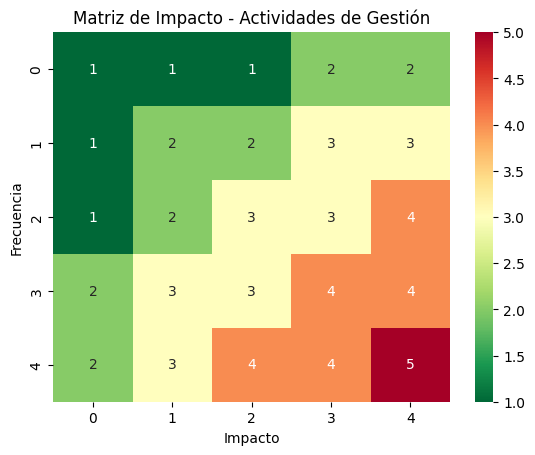

In [ ]:
# 1.  Perdida esperada por promedio simple
ps=np.round(np.mean(MEs),3)
print("EL promedio simple de severidad por atender fallas es:",ps,"MUSD")

#========================================================================================================================

# 2. Como no todos los contendeores tienen la misma frecuencia (Pocos son los que sufren perdidas extremas)
# se debe ponderar por la frecuencia
pp=np.round(np.sum(MEf*MEs)/np.sum(MEf),3)
print("El promedio ponderado de severidad por atender una falla es:",pp,"MUSD")

#========================================================================================================================

#Procedemos con la creacion de la matriz de impacto - MI
# Esta matriz me determina que actividades debo hacer para gestionar los riesgos segun su nivel
# Por ejemplo: asignar un especialista a cuidar los de nivel 5, revisar con mayor frecuencia, etc
MI=np.array([[1,1,1,2,2],
            [1,2,2,3,3],
            [1,2,3,3,4],
            [2,3,3,4,4],
            [2,3,4,4,5]])

# 3. Se procede a determinar la perdidad ponderada teniendo igualmente la matriz de impacto - nivel de riesgo
pnr=np.round(np.sum(MEf*MEs*MI)/np.sum(MEf*MI),3)
print("El promedio ponderado de severidad por nivel por atender una falla (perdidas esperadas) es:",pnr," MUSD")

#========================================================================================================================


# Mostramos la MI
plt.figure()
sns.heatmap(MI,annot=True,fmt='.0f',cmap='RdYlGn_r')
plt.ylabel('Frecuencia')
plt.xlabel('Impacto')
plt.title('Matriz de Impacto - Actividades de Gestión')
plt.show()

Ingresar el nivel de gestion (1,2,3,4):2
El costo de atender una falla con nivel de gestion 2 es 1.625  KUSD


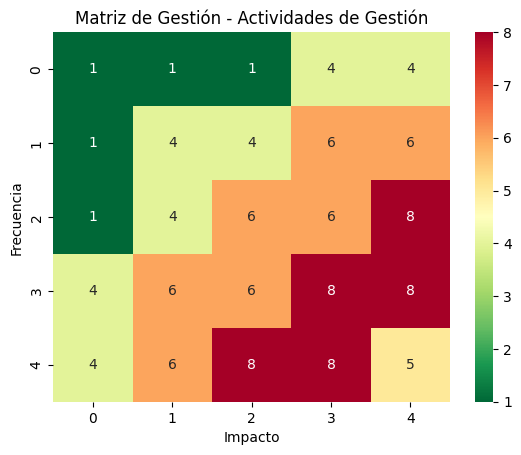

In [ ]:
# 4. Se procede a determinar la perdida ponderada, teniendo igualmente la matriz de gestion

# creamos la matriz de gestion
NG=np.int32(input("Ingresar el nivel de gestion (1,2,3,4):")) # pedimos el nivel de gestion necesario
MG=np.copy(MI)

# creamos un loop para revisar el nivel de gestion
for i in range(5):
  for j in range(5):
    if MG[i,j]>1 and MG[i,j]<5:
      MG[i,j]=MG[i,j]*NG

#creamos la medida
png=np.round(np.sum(MEf*MEs*MI)/np.sum(MEf*MG),3)
print("El costo de atender una falla con nivel de gestion",NG,"es",png," KUSD")

# Mostramos la MG

plt.figure()
sns.heatmap(MG,annot=True,fmt='.0f',cmap='RdYlGn_r')
plt.ylabel('Frecuencia')
plt.xlabel('Impacto')
plt.title('Matriz de Gestión - Actividades de Gestión')
plt.show()

6. Creamos la matriz con niveles de riesgo en cada celda

In [ ]:
fila=np.int32(input("Ingresar el nivel de frecuencia: "))
col=np.int32(input("Ingresar el nivel para la severidad: "))
df[(df.iloc[:,1]==fila)&(df.iloc[:,3]==col)]

Ingresar el nivel de frecuencia: 2
Ingresar el nivel para la severidad: 2


,Freq,Nivel_f,Sev,Nivel_S,LDA,Nivel_LDA,Riesgos
4,7,2.0,1.2105,2.0,8.4735,4.0,"Errores en la interfaz de usuario, fallas en f..."
41,7,2.0,1.3855,2.0,9.6985,2.0,"Errores en la interfaz de usuario, fallas en f..."
44,6,2.0,1.2693,2.0,7.6158,2.0,"Errores en la interfaz de usuario, fallas en f..."
56,7,2.0,1.827,2.0,12.789,2.0,"Errores en la interfaz de usuario, fallas en f..."
102,7,2.0,1.749,2.0,12.243,2.0,"Errores en la interfaz de usuario, fallas en f..."
110,6,2.0,1.6892,2.0,10.1352,2.0,"Errores en la interfaz de usuario, fallas en f..."
143,6,2.0,2.1317,2.0,12.7902,2.0,"Errores en la interfaz de usuario, fallas en f..."
157,6,2.0,2.6077,2.0,15.6462,2.0,"Degradación del rendimiento por varias horas, ..."
191,5,2.0,2.2048,2.0,11.024,2.0,"Errores en la interfaz de usuario, fallas en f..."
196,6,2.0,1.8272,2.0,10.9632,2.0,"Errores en la interfaz de usuario, fallas en f..."


7. Procedemos con el calculo de las perdidas agregadas (LDA)

El limite de las perdidas esperadas es:  9.45111269614836
El limmite inferior de las perdidas C3 es:  102.9021000000008
El numero de fallas(transacciones) con perdidas inferiores a C1 es:  1952
El numero de fallas(transacciones con perdidas inferiores a C2 es:  1370
El numero de fallas(transacciones con perdidas superiores al OpVar es:  10
fallas(transacciones con Perdidas Esperadas:  1952
fallas(transacciones con Perdidas No Esperadas:  1370
fallas(transacciones con Perdidas Catastroficas:  10
El porcentaje de eventos de riesgo C1 es: 0.5858343337334934
El porcentaje de eventos de riesgo C2 es: 0.41116446578631455
El porcentaje de eventos de riesgo C3 es: 0.003001200480192077
Ingresar el nivel de gestion: 2
El numero de fallas(transacciones C1 luego de una gestion 1:2 es: 2652 
El numero de fallas(transacciones C3 luego de una gestion 1:2 es: 0 
El numero de fallas(transacciones C2 luego de una gestion 1:2 es: 680 
El numero de fallas(transacciones) que migran de C2 a C1 son: 700
La p

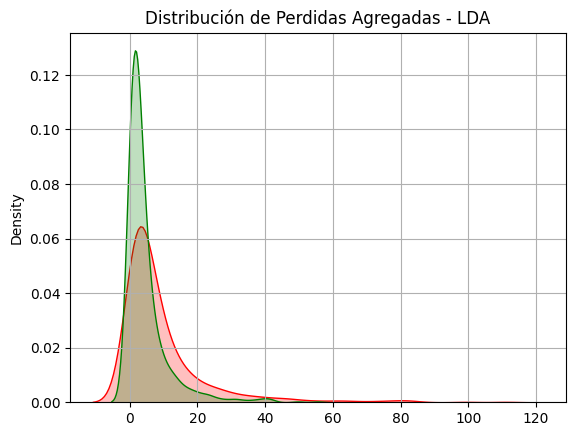

In [ ]:
# Se procede con la grafica de la distribucion de perdidas (LDA)
LDA = np.array(df.iloc[:,4])
# Limite superior de C1, osea la media de la LDA
LC1 = np.mean(LDA); print("El limite de las perdidas esperadas es: ",LC1)

# Es el limite inferior de las perdidas tipo C3
OpVar = np.percentile(LDA,99.9); print("El limmite inferior de las perdidas C3 es: ",OpVar)
print("==============================================================================================")


#Contabilizamos el numero de contenedores por categoria de riesgo

# Categoria C1
nc_c1 = np.sum(df[df.iloc[:,4]<LC1].iloc[:,0])
print("El numero de fallas(transacciones) con perdidas inferiores a C1 es: ",nc_c1)

# Categoria C2
nc_c2 = np.sum(df[(df.iloc[:,4]>=LC1)&(df.iloc[:,4]<OpVar)].iloc[:,0])
print("El numero de fallas(transacciones con perdidas inferiores a C2 es: ",nc_c2)

# Categoria C3
nc_c3 = np.sum(df[df.iloc[:,4]>=OpVar].iloc[:,0])
print("El numero de fallas(transacciones con perdidas superiores al OpVar es: ",nc_c3)

print("==============================================================================================")


print("fallas(transacciones con Perdidas Esperadas: ",nc_c1)
print("fallas(transacciones con Perdidas No Esperadas: ",nc_c2)
print("fallas(transacciones con Perdidas Catastroficas: ",nc_c3)

print("==============================================================================================")


# Los valores porcentuales del riesgo son:

print("El porcentaje de eventos de riesgo C1 es:",nc_c1/np.sum(df.iloc[:,0]))
print("El porcentaje de eventos de riesgo C2 es:",nc_c2/np.sum(df.iloc[:,0]))
print("El porcentaje de eventos de riesgo C3 es:",nc_c3/np.sum(df.iloc[:,0]))

print("==============================================================================================")

# Gestion de riesgos
nimp = np.array(df.iloc[:,5]+1) # niveles de impacto
ngest = np.int32(input("Ingresar el nivel de gestion: "))
ng2 = nimp*ngest
df['Nivel LDA'] = nimp
df['Nivel Gestion']=ng2

print("==============================================================================================")

# Se procede a determinar la distribucion de perdidas gestionada
LDA_G = LDA*(nimp/ng2)

# Procedemos a contar las fallas

nc_c1_g = np.sum(df[LDA_G<LC1].iloc[:,0])
print(f"El numero de fallas(transacciones C1 luego de una gestion 1:{ngest} es: {nc_c1_g} ")
nc_c3_g= np.sum(df[LDA_G>=OpVar].iloc[:,0])
print(f"El numero de fallas(transacciones C3 luego de una gestion 1:{ngest} es: {nc_c3_g} ")
nc_c2_g = np.sum(df[(LDA_G>=LC1)&(LDA_G<OpVar)].iloc[:,0])
print(f"El numero de fallas(transacciones C2 luego de una gestion 1:{ngest} es: {nc_c2_g} ")

# Valor capturado financiero

nc1g = nc_c1_g-nc_c1 # numero de fallas(transacciones) que migran  de c2 a c1 por la gestion de riesgos
print("El numero de fallas(transacciones) que migran de C2 a C1 son:",nc1g)
PProm=1.9296 # perdida promedio de una falla(transaccion) - sacada del excel
print("La perdida promedio de una falla(transacciones es:",PProm)
CGest = 0.2518 # costos de gestion - sacado de la hoja 3 del excel
print("Los costos de gestion por falla(transaccion) son:",CGest)
VCapt = nc1g*(PProm-(CGest*ngest)) #Valor capturado financiero - evito que las fallas sean C3
print("El valor capturado financiero es:",VCapt)

print("==============================================================================================")
# Graficamos

plt.figure()
sns.kdeplot(LDA,fill=True,color='Red')
sns.kdeplot(LDA_G,fill=True,color='Green')
plt.title("Distribución de Perdidas Agregadas - LDA")
plt.grid()
plt.show()

# Analisis de Resultados

### Métricas Estadísticas del Riesgo
*   **Pérdida Esperada por Promedio Simple (`ps`)**: La severidad promedio por atender fallas fue de **4.113 MUSD**.
*   **Pérdida Esperada Ponderada (`pp`)**: Considerando la frecuencia de los contenedores, el promedio ponderado de severidad por atender una falla fue de **2.21 MUSD**.
*   **Pérdida Esperada Ponderada por Nivel de Riesgo (`pnr`)**: Utilizando una Matriz de Impacto (`MI`) predefinida para actividades de gestión, la severidad ponderada por nivel de riesgo fue de **2.96 MUSD**.
*   **Costo de Gestión (`png`)**: Para un nivel de gestión (`NG`) de **2** (ingresado por el usuario), el costo de atender una falla con este nivel de gestión fue de **1.625 KUSD**.

### Análisis de Pérdidas Agregadas (LDA)
Se realizó un análisis detallado de la distribución de pérdidas agregadas, identificando:
*   **Límite de Pérdida Esperada (`LC1`)**: El promedio de las pérdidas agregadas fue de **9.451 MUSD**.
*   **Operational Value at Risk (`OpVar`)**: El percentil 99.9 de las pérdidas agregadas, representando el límite inferior de las pérdidas catastróficas (categoría C3), fue de **102.902 MUSD**.

#### Distribución de Eventos por Categoría (Riesgo Inherente):
*   **Eventos C1 (Pérdidas Esperadas, < LC1)**: **1952** fallas (58.58% del total de transacciones fallidas).
*   **Eventos C2 (Pérdidas No Esperadas, >= LC1 y < OpVar)**: **1370** fallas (41.11% del total de transacciones fallidas).
*   **Eventos C3 (Pérdidas Catastróficas, >= OpVar)**: **10** fallas (0.30% del total de transacciones fallidas).

#### Impacto de la Gestión (Riesgo Residual):
Para un nivel de gestión `ngest = 2`:
*   **Eventos C1**: Aumentaron a **2652** fallas, indicando que **700** fallas migraron de C2 a C1.
*   **Eventos C2**: Disminuyeron a **680** fallas.
*   **Eventos C3**: Se redujeron a **0** fallas, lo que demuestra una alta efectividad de la gestión en la eliminación de eventos catastróficos.

#### Valor Capturado Financieramente (`VCapt`):
Con una pérdida promedio por falla (`PProm`) de **1.9296 KUSD** y costos de gestión por falla (`CGest`) de **0.2518 KUSD** (para un `ngest = 2`), el valor capturado financieramente fue de **998.2 KUSD**. Este valor representa el beneficio económico de la gestión del riesgo al evitar que eventos de mayor impacto ocurran o se eleven a categorías más graves.

## Conclusiones
El análisis cuantitativo del riesgo operacional revela una clara distribución de las pérdidas, con una mayoría de eventos en la categoría de pérdidas esperadas (C1). Sin embargo, la existencia de eventos C2 y C3, aunque en menor proporción, resalta la necesidad de una gestión activa.

La implementación de un nivel de gestión 2 demostró ser altamente efectiva, logrando migrar **700** eventos de riesgo de la categoría C2 a C1 y eliminando por completo los eventos catastróficos C3. Esto se traduce en un valor capturado financiero significativo de **998.2 KUSD**, lo que justifica la inversión en las actividades de gestión de riesgo propuestas.